In [1]:
# Install yfinance to fetch live stock market data
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set visualization style
sns.set_theme(style="darkgrid")
print("Setup complete! Libraries imported.")

Setup complete! Libraries imported.


In [2]:
# 1. Data Collection
ticker_symbol = "AAPL" # You can change this to MSFT, GOOGL, TSLA, etc.
stock_data = yf.download(ticker_symbol, start="2018-01-01", end="2024-01-01")

# 2. Data Preprocessing & Feature Engineering
df = stock_data.copy()

# Flatten column multi-index if yfinance returns one
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Create Moving Averages (50-day and 200-day)
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

# Define the Target Variable: Next day's closing price
df['Target_Next_Close'] = df['Close'].shift(-1)

# Drop rows with missing values (due to rolling averages and shift)
df.dropna(inplace=True)

print(f"Dataset shape after preprocessing: {df.shape}")
display(df.tail())

/tmp/ipykernel_886/3101069073.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Dataset shape after preprocessing: (1309, 8)


Price,Close,High,Low,Open,Volume,MA_50,MA_200,Target_Next_Close
Date,,,,,,,,
2023-12-21,192.335114,194.706215,191.169334,193.738023,46482500,182.815150,175.914170,191.268143
2023-12-22,191.268143,193.056339,190.645726,192.829099,37149600,183.074543,176.129635,190.724777
2023-12-26,190.724777,191.554656,190.507426,191.278030,28919300,183.359772,176.352666,190.823532
2023-12-27,190.823532,191.169322,188.788347,190.171493,48087700,183.649542,176.566498,191.248367
2023-12-28,191.248367,192.315361,190.843302,191.801620,34049900,183.978789,176.772025,190.211044


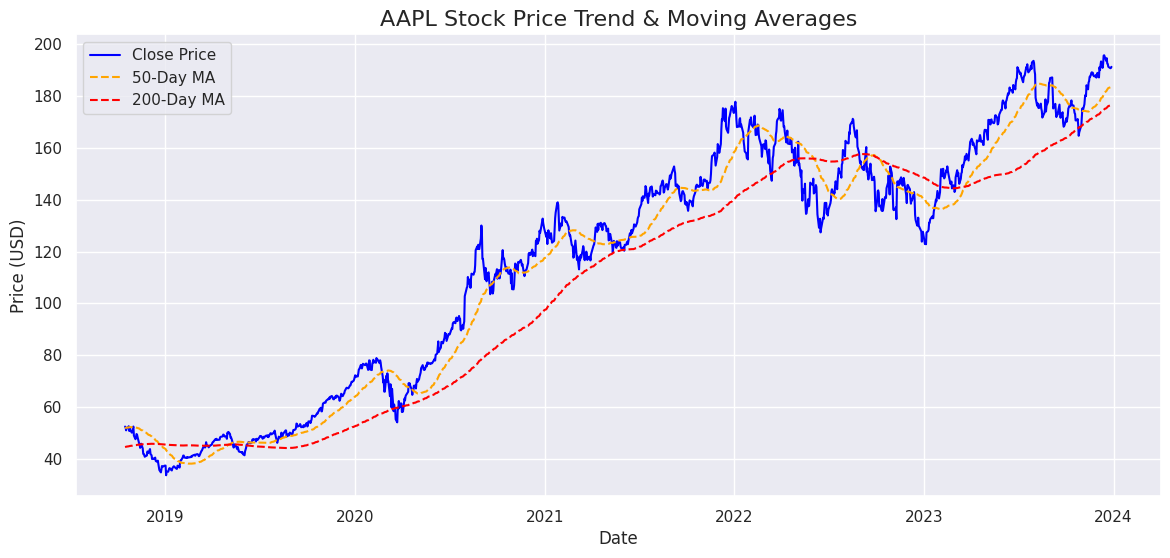

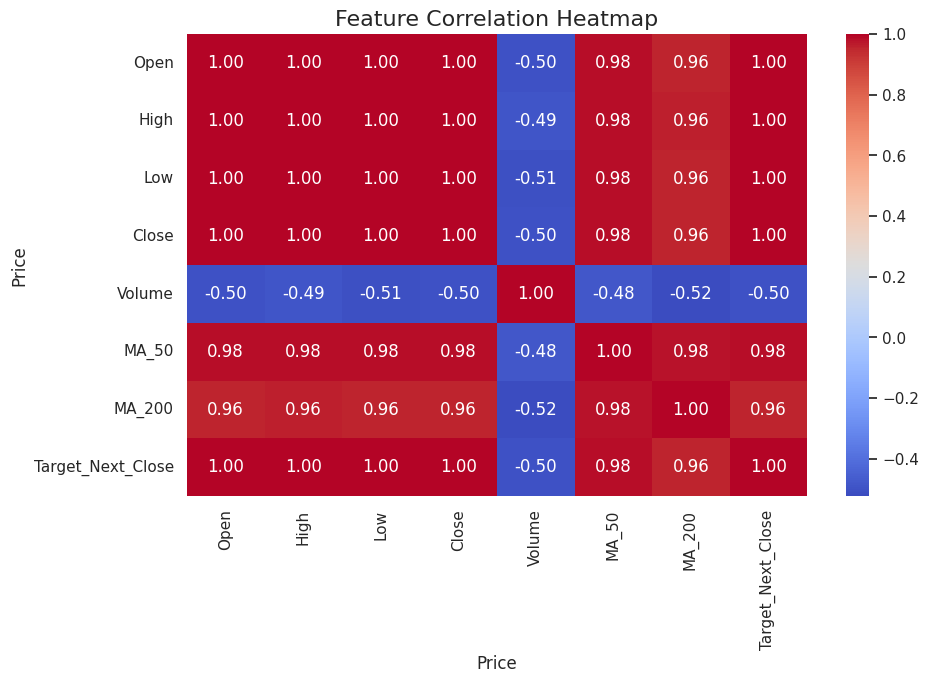

In [3]:
# 1. Historical Closing Price Trend
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price', color='blue')
plt.plot(df.index, df['MA_50'], label='50-Day MA', color='orange', linestyle='--')
plt.plot(df.index, df['MA_200'], label='200-Day MA', color='red', linestyle='--')
plt.title(f"{ticker_symbol} Stock Price Trend & Moving Averages", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 6))
# Select only numerical columns for correlation
numerical_df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'MA_50', 'MA_200', 'Target_Next_Close']]
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

In [4]:
# Define Features (X) and Target (y)
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_50', 'MA_200']
X = df[features]
y = df['Target_Next_Close']

# Train-Test Split (Chronological split, NOT random)
split_idx = int(len(df) * 0.8) # 80% for training, 20% for testing
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training data size: {len(X_train)} | Testing data size: {len(X_test)}")

# Initialize and Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Generate Predictions
predictions = model.predict(X_test)

Training data size: 1047 | Testing data size: 262


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 6.68
Mean Squared Error (MSE):  92.88
Root Mean Squared Error (RMSE): 9.64
R² Score: 0.7371


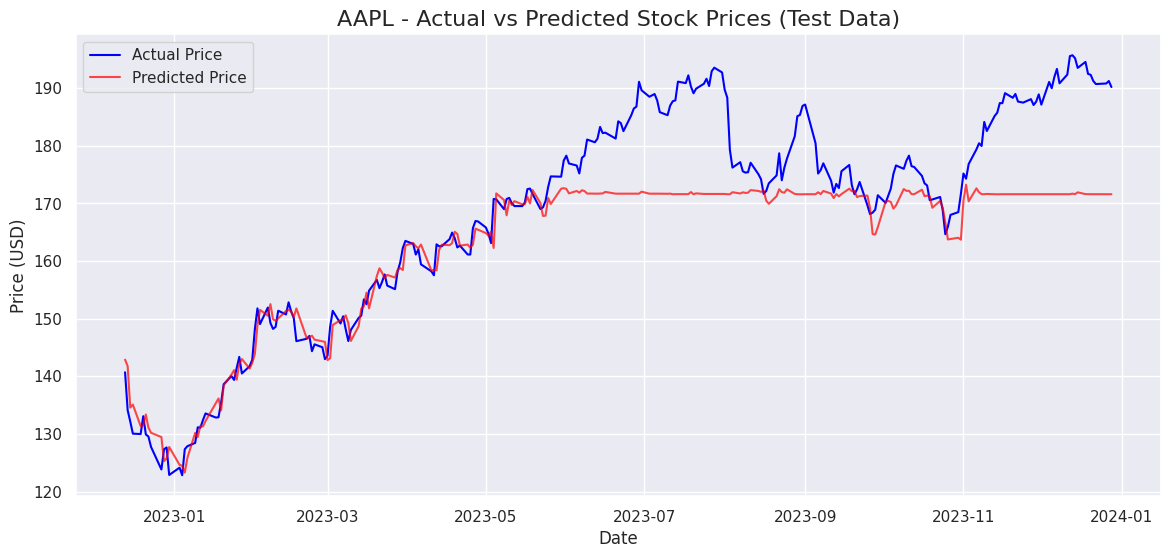

In [5]:
# 1. Performance Evaluation Metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE):  {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# 2. Visualization Dashboard: Actual vs Predicted
plt.figure(figsize=(14, 6))

# Plot actual prices
plt.plot(y_test.index, y_test.values, label="Actual Price", color='blue')

# Plot predicted prices
plt.plot(y_test.index, predictions, label="Predicted Price", color='red', alpha=0.7)

plt.title(f"{ticker_symbol} - Actual vs Predicted Stock Prices (Test Data)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()